# Content-Based Filtering from Scratch

**Core idea**: recommend items similar to what a user has liked before, based on the *content* of the items — not other users' behavior.

This means we need to represent each item as a feature vector, and each user as a profile derived from the items they've liked. Then recommendation is just finding items whose vectors are close to the user's profile vector.

We implement:
1. **Genre-based features** — binary flags for each of 19 genres (already in the data)
2. **TF-IDF on titles** — extract word-level features from movie titles
3. **Combined features** — genre + title, weighted
4. **User profiles** — weighted average of liked item vectors
5. **Filter bubble analysis** — show how this approach narrows recommendations over time

No other users' ratings needed — only the target user's history and item metadata.

## 1. Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from collections import Counter

DATA_DIR = Path("../data/ml-100k")

ratings = pd.read_csv(
    DATA_DIR / "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

GENRE_NAMES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]

movies = pd.read_csv(
    DATA_DIR / "u.item",
    sep="|",
    encoding="latin-1",
    names=["item_id", "title", "release_date", "video_date", "imdb_url"] + GENRE_NAMES,
)
movies = movies[["item_id", "title"] + GENRE_NAMES].copy()

print(f"Movies: {len(movies)}")
print(f"Ratings: {len(ratings):,}")
print(f"Genres: {GENRE_NAMES}")
movies.head(3)

Movies: 1682
Ratings: 100,000
Genres: ['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,item_id,title,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## 2. Train/Test Split

Same leave-one-out split as section 01 so we can compare results directly.

In [2]:
ratings_sorted = ratings.sort_values(["user_id", "timestamp"])
test = ratings_sorted.groupby("user_id").tail(1).copy()
train = ratings_sorted.drop(test.index).copy()

user_ids = sorted(ratings["user_id"].unique())
item_ids = sorted(ratings["item_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}
N_USERS, N_ITEMS = len(user_ids), len(item_ids)

R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for row in train.itertuples():
    R[user2idx[row.user_id], item2idx[row.item_id]] = row.rating

print(f"Train: {len(train):,} | Test: {len(test):,} | Matrix: {R.shape}")

Train: 99,057 | Test: 943 | Matrix: (943, 1682)


## 3. Feature Representation 1: Genre Vectors

The simplest item representation: a 19-dimensional binary vector, one entry per genre.

Toy Story → [0, 0, 0, 1, 1, 1, 0, 0, 0, ...]  (Animation=1, Children's=1, Comedy=1)

Genre matrix shape: (1682, 19)
Items with no genre: 0
Avg genres per item: 1.7


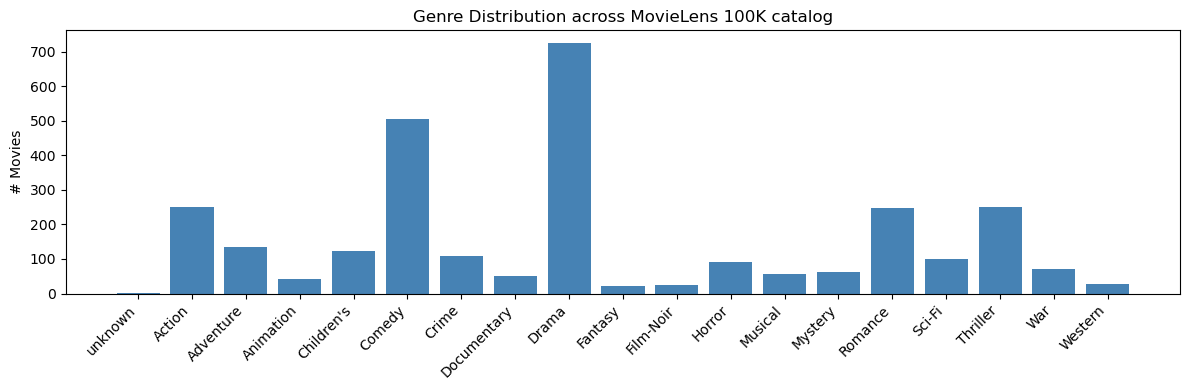


Toy Story genres: ['Animation', "Children's", 'Comedy']


In [3]:
# Build genre matrix: rows = items (in item_ids order), cols = 19 genres
# We only keep items that appear in our ratings (item_ids list)
movies_indexed = movies.set_index("item_id").reindex(item_ids)
genre_matrix = movies_indexed[GENRE_NAMES].values.astype(np.float32)  # (N_ITEMS, 19)

print(f"Genre matrix shape: {genre_matrix.shape}")
print(f"Items with no genre: {(genre_matrix.sum(axis=1) == 0).sum()}")
print(f"Avg genres per item: {genre_matrix.sum(axis=1).mean():.1f}")

# Genre distribution
genre_counts = genre_matrix.sum(axis=0)
plt.figure(figsize=(12, 4))
plt.bar(GENRE_NAMES, genre_counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Genre Distribution across MovieLens 100K catalog")
plt.ylabel("# Movies")
plt.tight_layout()
plt.show()

# Show Toy Story's genre vector
toy_story_idx = item2idx[1]
toy_story_genres = [g for g, v in zip(GENRE_NAMES, genre_matrix[toy_story_idx]) if v > 0]
print(f"\nToy Story genres: {toy_story_genres}")

## 4. Feature Representation 2: TF-IDF on Titles

Genre flags are coarse — "Drama" covers thousands of films. Title words add finer-grained signal: words like "Star", "Wars", "Space" distinguish sci-fi from drama without needing explicit tags.

**TF-IDF** (Term Frequency × Inverse Document Frequency):
- **TF**: how often a word appears in this title
- **IDF**: penalize words that appear in many titles ("The", "A", "of")
- Result: rare, distinguishing words get high weight; common words get low weight

$$\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \log\frac{N}{\text{DF}(w)}$$

In [4]:
def tokenize(title: str) -> list[str]:
    """Lowercase, strip year and punctuation, split into words."""
    title = re.sub(r"\(\d{4}\)", "", title)   # remove year
    title = re.sub(r"[^a-z\s]", "", title.lower())
    stopwords = {"the", "a", "an", "of", "in", "and", "to", "is", "it", "s"}
    return [w for w in title.split() if w and w not in stopwords]


# Build vocabulary from all titles
titles = movies_indexed["title"].fillna("").tolist()
tokenized = [tokenize(t) for t in titles]

vocab = sorted(set(w for doc in tokenized for w in doc))
word2idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"Vocabulary size: {V} unique words from {len(titles)} titles")

# Build TF matrix: (N_ITEMS, V)
TF = np.zeros((N_ITEMS, V), dtype=np.float32)
for i, tokens in enumerate(tokenized):
    if not tokens:
        continue
    counts = Counter(tokens)
    for w, c in counts.items():
        TF[i, word2idx[w]] = c / len(tokens)   # normalize by title length

# IDF: log(N / document_frequency), with +1 smoothing
DF = (TF > 0).sum(axis=0)   # how many titles contain each word
IDF = np.log((N_ITEMS + 1) / (DF + 1)) + 1   # +1 to avoid negatives on very common words

TFIDF = TF * IDF   # (N_ITEMS, V)

print(f"TF-IDF matrix shape: {TFIDF.shape}")
print(f"Sparsity: {(TFIDF == 0).mean():.1%}")

# Show highest TF-IDF words for a few movies
for item_id, label in [(1, "Toy Story"), (50, "Star Wars"), (269, "Silence of the Lambs")]:
    idx = item2idx[item_id]
    top_words = np.argsort(TFIDF[idx])[::-1][:5]
    words_scores = [(vocab[w], TFIDF[idx, w]) for w in top_words if TFIDF[idx, w] > 0]
    print(f"  {label}: {words_scores}")

Vocabulary size: 2360 unique words from 1682 titles
TF-IDF matrix shape: (1682, 2360)
Sparsity: 99.9%
  Toy Story: [('toy', 3.8675930068154303), ('story', 3.1155543084272934)]
  Star Wars: [('wars', 3.8675930068154303), ('star', 2.860141496544298)]
  Silence of the Lambs: [('monty', 3.5210194165354576), ('full', 3.5210194165354576)]


## 5. Combined Feature Matrix

Concatenate genre flags and TF-IDF title vectors into one feature vector per item.
Then L2-normalize so cosine similarity is just a dot product.

In [5]:
def l2_normalize(M: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10
    return M / norms


# Weight genre features more heavily — they're denser and more reliable than title words
GENRE_WEIGHT = 3.0

item_features = np.hstack([
    genre_matrix * GENRE_WEIGHT,   # (N_ITEMS, 19) — genre binary flags
    TFIDF,                         # (N_ITEMS, V) — title TF-IDF
])  # (N_ITEMS, 19+V)

item_features_norm = l2_normalize(item_features)   # (N_ITEMS, 19+V) — unit vectors

print(f"Combined feature matrix: {item_features.shape}")
print(f"Features per item: {item_features.shape[1]} ({len(GENRE_NAMES)} genres + {V} title words)")

# Item-item cosine similarity is now just a dot product of normalized rows
# (we'll compute on-the-fly rather than materializing the full N×N matrix)
toy_story_vec = item_features_norm[toy_story_idx]
item_sims = item_features_norm @ toy_story_vec   # (N_ITEMS,)
top10 = np.argsort(item_sims)[::-1][1:11]

print("\nContent-based: most similar to Toy Story (1995):")
for rank, idx in enumerate(top10, 1):
    iid = idx2item[idx]
    t = movies.loc[movies["item_id"] == iid, "title"].values[0]
    g = [g for g, v in zip(GENRE_NAMES, genre_matrix[idx]) if v > 0]
    print(f"  {rank:2}. {t}  [{', '.join(g)}]  sim={item_sims[idx]:.3f}")

Combined feature matrix: (1682, 2379)
Features per item: 2379 (19 genres + 2360 title words)

Content-based: most similar to Toy Story (1995):
   1. Aladdin and the King of Thieves (1996)  [Animation, Children's, Comedy]  sim=0.576
   2. Land Before Time III: The Time of the Great Giving (1995) (V)  [Animation, Children's]  sim=0.506
   3. Goofy Movie, A (1995)  [Animation, Children's, Comedy, Romance]  sim=0.482
   4. Beavis and Butt-head Do America (1996)  [Animation, Comedy]  sim=0.451
   5. Winnie the Pooh and the Blustery Day (1968)  [Animation, Children's]  sim=0.448
   6. Space Jam (1996)  [Adventure, Animation, Children's, Comedy, Fantasy]  sim=0.442
   7. Little Big League (1994)  [Children's, Comedy]  sim=0.440
   8. Grand Day Out, A (1992)  [Animation, Comedy]  sim=0.439
   9. D3: The Mighty Ducks (1996)  [Children's, Comedy]  sim=0.423
  10. Philadelphia Story, The (1940)  [Comedy, Romance]  sim=0.406


## 6. Building User Profiles

A user profile is a weighted average of the feature vectors of items they've liked.
Items rated highly contribute more; low-rated items contribute less (or can be subtracted).

$$\vec{p}_u = \frac{\sum_{i \in \text{rated}(u)} w(r_{ui}) \cdot \vec{f}_i}{\sum_{i \in \text{rated}(u)} w(r_{ui})}$$

where $w(r) = r - \bar{r}_u$ mean-centers the weights so disliked items pull the profile *away*.

In [6]:
def build_user_profile(user_idx: int, use_mean_centering: bool = True) -> np.ndarray:
    """
    Build a user profile vector as a weighted average of item feature vectors.
    
    With mean_centering: items rated above average push the profile toward them;
    items rated below average push the profile away. This captures taste, not just
    activity.
    
    Without mean_centering: any rating contributes positively (a 1-star movie still
    adds its genre to the user's profile).
    """
    user_ratings = R[user_idx]       # (N_ITEMS,) — 0 = not rated
    rated_mask = user_ratings > 0

    if not rated_mask.any():
        return np.zeros(item_features_norm.shape[1])

    if use_mean_centering:
        mean_rating = user_ratings[rated_mask].mean()
        weights = user_ratings - mean_rating   # negative for disliked items
    else:
        weights = user_ratings.copy()

    weights = np.where(rated_mask, weights, 0)
    weight_sum = np.abs(weights).sum()

    if weight_sum < 1e-10:
        return item_features_norm[rated_mask].mean(axis=0)

    # Weighted sum of item feature vectors: (N_ITEMS,) @ (N_ITEMS, F) = (F,)
    profile = weights @ item_features_norm   # (F,)
    return profile / weight_sum


# Inspect a user's profile
active_user_id = ratings.groupby("user_id").size().sort_values(ascending=False).index[3]
u = user2idx[active_user_id]

profile = build_user_profile(u, use_mean_centering=True)
print(f"User {active_user_id}: profile vector shape = {profile.shape}")

# Which genre dimensions dominate this user's profile?
genre_weights = profile[:len(GENRE_NAMES)]
print("\nTop genre dimensions in this user's profile:")
for i in np.argsort(np.abs(genre_weights))[::-1][:6]:
    direction = "liked" if genre_weights[i] > 0 else "disliked"
    print(f"  {GENRE_NAMES[i]:15s}: {genre_weights[i]:+.4f}  ({direction})")

User 450: profile vector shape = (2379,)

Top genre dimensions in this user's profile:
  Comedy         : -0.0483  (disliked)
  Drama          : +0.0472  (liked)
  Romance        : +0.0169  (liked)
  Adventure      : -0.0133  (disliked)
  Children's     : -0.0108  (disliked)
  War            : +0.0080  (liked)


## 7. Content-Based Recommendation

Score all items by cosine similarity to the user's profile vector, then rank.

In [7]:
def cb_scores(user_idx: int) -> np.ndarray:
    """
    Score all items by cosine similarity to user's content profile.
    One dot product of (F,) profile against (N_ITEMS, F) item matrix.
    """
    profile = build_user_profile(user_idx)
    norm = np.linalg.norm(profile)
    if norm < 1e-10:
        # No profile signal — fall back to item popularity
        return (R > 0).sum(axis=0).astype(np.float32)
    profile_norm = profile / norm
    return item_features_norm @ profile_norm   # (N_ITEMS,)


def show_recs(user_id: int, score_fn, label: str, K: int = 10):
    u = user2idx[user_id]
    scores = score_fn(u)
    unrated = np.where(R[u] == 0, scores, -np.inf)
    top_k = np.argsort(unrated)[::-1][:K]

    rated_idxs = np.where(R[u] > 0)[0]
    top_rated = rated_idxs[np.argsort(R[u][rated_idxs])[::-1][:5]]

    print(f"\n=== {label} — User {user_id} ===")
    print("Highly rated in training:")
    for idx in top_rated:
        iid = idx2item[idx]
        t = movies.loc[movies["item_id"] == iid, "title"].values[0]
        g = [g for g, v in zip(GENRE_NAMES, genre_matrix[idx]) if v > 0]
        print(f"  ★{R[u,idx]:.0f}  {t}  [{', '.join(g)}]")

    print(f"\nTop-{K} recommendations:")
    for rank, idx in enumerate(top_k, 1):
        iid = idx2item[idx]
        t = movies.loc[movies["item_id"] == iid, "title"].values[0]
        g = [g for g, v in zip(GENRE_NAMES, genre_matrix[idx]) if v > 0]
        print(f"  {rank:2}. {t}  [{', '.join(g)}]")


show_recs(active_user_id, cb_scores, "Content-Based")


=== Content-Based — User 450 ===
Highly rated in training:
  ★5  Great Expectations (1998)  [Drama, Romance]
  ★5  Amadeus (1984)  [Drama, Mystery]
  ★5  Clockwork Orange, A (1971)  [Sci-Fi]
  ★5  Secret Garden, The (1993)  [Children's, Drama]
  ★5  GoodFellas (1990)  [Crime, Drama]

Top-10 recommendations:
   1. 187 (1997)  [Drama]
   2. 8 1/2 (1963)  [Drama]
   3. I Don't Want to Talk About It (De eso no se habla) (1993)  [Drama]
   4. Flower of My Secret, The (Flor de mi secreto, La) (1995)  [Drama]
   5. Two or Three Things I Know About Her (1966)  [Drama]
   6. I, Worst of All (Yo, la peor de todas) (1990)  [Drama]
   7. My Life and Times With Antonin Artaud (En compagnie d'Antonin Artaud) (1993)  [Drama]
   8. My Life as a Dog (Mitt liv som hund) (1985)  [Drama]
   9. Once Upon a Time... When We Were Colored (1995)  [Drama]
  10. Death in the Garden (Mort en ce jardin, La) (1956)  [Drama]


## 8. Evaluation: Hit Rate@K and NDCG@K

In [8]:
def evaluate(score_fn, R, test_df, K=10):
    hits, ndcgs = [], []
    for user_id in test_df["user_id"].unique():
        u = user2idx[user_id]
        test_item_id = test_df.loc[test_df["user_id"] == user_id, "item_id"].values[0]
        if test_item_id not in item2idx:
            continue
        test_item_idx = item2idx[test_item_id]

        scores = score_fn(u)
        unrated_mask = R[u] == 0
        unrated_mask[test_item_idx] = True
        candidate_scores = np.where(unrated_mask, scores, -np.inf)

        rank = (candidate_scores > candidate_scores[test_item_idx]).sum() + 1
        hit = int(rank <= K)
        hits.append(hit)
        ndcgs.append(hit / np.log2(rank + 1))

    return {
        f"HitRate@{K}": round(float(np.mean(hits)), 4),
        f"NDCG@{K}": round(float(np.mean(ndcgs)), 4),
    }


import time

# Popularity baseline (same as section 01)
item_popularity = (R > 0).sum(axis=0).astype(np.float32)

print("Evaluating popularity baseline...")
t0 = time.time()
pop_results = evaluate(lambda u: item_popularity, R, test, K=10)
print(f"  {pop_results}  ({time.time()-t0:.1f}s)")

print("\nEvaluating Content-Based (genres + TF-IDF titles)...")
t0 = time.time()
cb_results = evaluate(cb_scores, R, test, K=10)
print(f"  {cb_results}  ({time.time()-t0:.1f}s)")

Evaluating popularity baseline...
  {'HitRate@10': 0.0859, 'NDCG@10': 0.045}  (0.1s)

Evaluating Content-Based (genres + TF-IDF titles)...


  {'HitRate@10': 0.0148, 'NDCG@10': 0.0079}  (1.6s)


Evaluating Content-Based (genres only)...


  {'HitRate@10': 0.0498, 'NDCG@10': 0.0398}  (0.2s)

                    Model  HitRate@10  NDCG@10
      Popularity Baseline      0.0859   0.0450
          CB — Genre Only      0.0498   0.0398
CB — Genre + Title TF-IDF      0.0148   0.0079


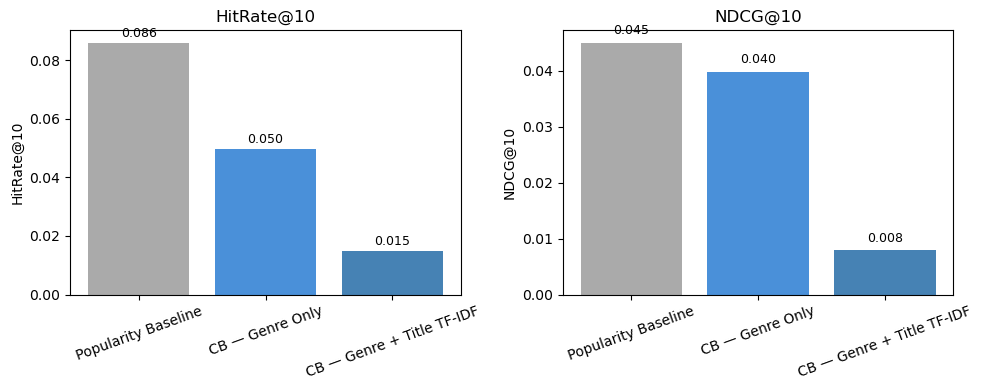

In [9]:
# Compare genre-only vs. combined features
item_features_genre_only = l2_normalize(genre_matrix.copy())

def cb_scores_genre_only(user_idx: int) -> np.ndarray:
    profile_vec = R[user_idx] @ item_features_genre_only
    norm = np.linalg.norm(profile_vec)
    if norm < 1e-10:
        return item_popularity
    return item_features_genre_only @ (profile_vec / norm)

print("Evaluating Content-Based (genres only)...")
t0 = time.time()
cb_genre_results = evaluate(cb_scores_genre_only, R, test, K=10)
print(f"  {cb_genre_results}  ({time.time()-t0:.1f}s)")

results = pd.DataFrame([
    {"Model": "Popularity Baseline", **pop_results},
    {"Model": "CB — Genre Only", **cb_genre_results},
    {"Model": "CB — Genre + Title TF-IDF", **cb_results},
])
print()
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#aaa", "#4a90d9", "steelblue"]
for ax, col in zip(axes, ["HitRate@10", "NDCG@10"]):
    bars = ax.bar(results["Model"], results[col], color=colors)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 9. The Filter Bubble

Content-based filtering only recommends items similar to what the user has already seen.
Over time, as the user rates more items, their profile becomes more and more specific —
and recommendations become more and more narrow.

Let's measure this directly: how does recommendation **diversity** change as a user rates more items?

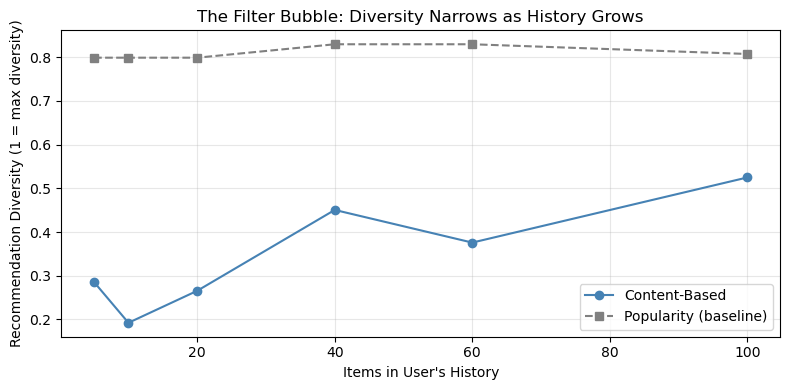

Diversity at 5 items vs 100 items:
  Content-Based: 0.286 → 0.525
  Popularity:    0.799 → 0.808


In [10]:
def genre_diversity(rec_item_idxs: list[int]) -> float:
    """
    Average pairwise dissimilarity between recommended items based on genre vectors.
    1.0 = all items share zero genres; 0.0 = all items are identical.
    """
    vecs = genre_matrix[rec_item_idxs]
    vecs_norm = l2_normalize(vecs + 1e-10)
    sim_matrix = vecs_norm @ vecs_norm.T
    n = len(rec_item_idxs)
    if n < 2:
        return 0.0
    # Average off-diagonal similarity → diversity = 1 - avg_sim
    avg_sim = (sim_matrix.sum() - np.trace(sim_matrix)) / (n * (n - 1))
    return float(1 - avg_sim)


# Pick a user with many ratings and simulate progressive rating history
power_user = ratings.groupby("user_id").size().sort_values(ascending=False).index[0]
u = user2idx[power_user]
all_rated = np.where(R[u] > 0)[0]

history_sizes = [5, 10, 20, 40, 60, 100]
cb_diversities, pop_diversities = [], []

for n_history in history_sizes:
    # Simulate user with only n_history items rated
    R_partial = np.zeros_like(R[u])
    R_partial[all_rated[:n_history]] = R[u][all_rated[:n_history]]

    # Build profile from partial history
    rated_mask = R_partial > 0
    mean_r = R_partial[rated_mask].mean()
    weights = np.where(rated_mask, R_partial - mean_r, 0)
    w_sum = np.abs(weights).sum()
    if w_sum < 1e-10:
        cb_diversities.append(0)
        pop_diversities.append(0)
        continue
    profile = (weights @ item_features_norm) / w_sum
    profile_norm = profile / (np.linalg.norm(profile) + 1e-10)

    # Top-10 recommendations
    cb_s = item_features_norm @ profile_norm
    unrated = np.where(R_partial == 0, cb_s, -np.inf)
    top10_cb = np.argsort(unrated)[::-1][:10].tolist()

    # Popularity top-10 (same for all)
    pop_unrated = np.where(R_partial == 0, item_popularity, -np.inf)
    top10_pop = np.argsort(pop_unrated)[::-1][:10].tolist()

    cb_diversities.append(genre_diversity(top10_cb))
    pop_diversities.append(genre_diversity(top10_pop))

plt.figure(figsize=(8, 4))
plt.plot(history_sizes, cb_diversities, marker="o", label="Content-Based", color="steelblue")
plt.plot(history_sizes, pop_diversities, marker="s", linestyle="--", label="Popularity (baseline)", color="gray")
plt.xlabel("Items in User's History")
plt.ylabel("Recommendation Diversity (1 = max diversity)")
plt.title("The Filter Bubble: Diversity Narrows as History Grows")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Diversity at 5 items vs 100 items:")
print(f"  Content-Based: {cb_diversities[0]:.3f} → {cb_diversities[-1]:.3f}")
print(f"  Popularity:    {pop_diversities[0]:.3f} → {pop_diversities[-1]:.3f}")

## 10. Cold Start: The Key Advantage over CF

Content-based can recommend **new items** the moment they're added to the catalog,
because scoring only requires the item's feature vector — no interaction data needed.

In [11]:
# Simulate adding a brand-new movie to the catalog
new_movie = {
    "title": "Galaxy Quest II (2025)",
    "genres": ["Action", "Adventure", "Comedy", "Sci-Fi"],
}

# Build feature vector for the new movie (same pipeline as the catalog)
genre_vec = np.zeros(len(GENRE_NAMES), dtype=np.float32)
for g in new_movie["genres"]:
    genre_vec[GENRE_NAMES.index(g)] = 1.0

title_vec = np.zeros(V, dtype=np.float32)
for w in tokenize(new_movie["title"]):
    if w in word2idx:
        title_vec[word2idx[w]] = 1.0 * IDF[word2idx[w]]

new_movie_vec = np.hstack([genre_vec * GENRE_WEIGHT, title_vec])
new_movie_vec_norm = new_movie_vec / (np.linalg.norm(new_movie_vec) + 1e-10)

# How similar is it to all users' profiles?
# Which users would be most interested in this new movie?
user_scores = []
for uid in user_ids[:100]:  # sample 100 users
    u = user2idx[uid]
    profile = build_user_profile(u)
    norm = np.linalg.norm(profile)
    if norm < 1e-10:
        continue
    score = float(new_movie_vec_norm @ (profile / norm))
    user_scores.append((uid, score))

user_scores.sort(key=lambda x: -x[1])
print(f"New movie: {new_movie['title']}  (genres: {new_movie['genres']})")
print("\nTop 5 users most likely to enjoy it (from their content profile):")
for uid, score in user_scores[:5]:
    u = user2idx[uid]
    rated = np.where(R[u] > 0)[0]
    top_genres = genre_matrix[rated].sum(axis=0)
    fav_genres = [GENRE_NAMES[i] for i in np.argsort(top_genres)[::-1][:3] if top_genres[i] > 0]
    print(f"  User {uid}: similarity={score:.3f}  (favorite genres: {fav_genres})")

print("\n→ This works with 0 ratings for the new movie.")
print("  CF would have nothing to work with. Content-based solves item cold start.")

New movie: Galaxy Quest II (2025)  (genres: ['Action', 'Adventure', 'Comedy', 'Sci-Fi'])

Top 5 users most likely to enjoy it (from their content profile):
  User 5: similarity=0.262  (favorite genres: ['Comedy', 'Action', 'Sci-Fi'])
  User 51: similarity=0.256  (favorite genres: ['Adventure', 'Action', 'Drama'])
  User 9: similarity=0.239  (favorite genres: ['Drama', 'Romance', 'Comedy'])
  User 42: similarity=0.227  (favorite genres: ['Drama', 'Comedy', 'Romance'])
  User 97: similarity=0.174  (favorite genres: ['Drama', 'Comedy', 'Sci-Fi'])

→ This works with 0 ratings for the new movie.
  CF would have nothing to work with. Content-based solves item cold start.


## 11. Explaining Recommendations

One of content-based filtering's biggest advantages: you can explain *why* something was recommended.

In [12]:
def explain_rec(user_id: int, target_item_id: int):
    """
    Show which items in the user's history are most similar to the recommended item,
    and which content features drive the similarity.
    """
    u = user2idx[user_id]
    target_idx = item2idx[target_item_id]
    target_vec = item_features_norm[target_idx]
    target_title = movies.loc[movies["item_id"] == target_item_id, "title"].values[0]
    target_genres = [g for g, v in zip(GENRE_NAMES, genre_matrix[target_idx]) if v > 0]

    # Which training items are most similar to the target?
    rated_idxs = np.where(R[u] > 0)[0]
    sims = item_features_norm[rated_idxs] @ target_vec
    top3 = rated_idxs[np.argsort(sims)[::-1][:3]]

    print(f"Why was '{target_title}' recommended to user {user_id}?")
    print(f"  Target genres: {target_genres}")
    print("\n  Most similar items they've rated:")
    for idx in top3:
        iid = idx2item[idx]
        t = movies.loc[movies["item_id"] == iid, "title"].values[0]
        g = [g for g, v in zip(GENRE_NAMES, genre_matrix[idx]) if v > 0]
        print(f"    ★{R[u,idx]:.0f}  {t}  [{', '.join(g)}]  (sim={item_features_norm[idx] @ target_vec:.3f})")

    # Which genre features overlap?
    profile = build_user_profile(u)
    genre_overlap = profile[:len(GENRE_NAMES)] * genre_matrix[target_idx]
    top_genre_reason = [(GENRE_NAMES[i], genre_overlap[i]) for i in np.argsort(np.abs(genre_overlap))[::-1][:3]
                        if genre_overlap[i] != 0]
    print(f"\n  Key genre signals: {top_genre_reason}")


# Get top rec for the active user and explain it
u = user2idx[active_user_id]
scores = cb_scores(u)
unrated = np.where(R[u] == 0, scores, -np.inf)
top_rec_idx = int(np.argmax(unrated))
top_rec_item_id = idx2item[top_rec_idx]

explain_rec(active_user_id, top_rec_item_id)

Why was '187 (1997)' recommended to user 450?
  Target genres: ['Drama']

  Most similar items they've rated:
    ★4  My Crazy Life (Mi vida loca) (1993)  [Drama]  (sim=0.730)
    ★5  What's Love Got to Do with It (1993)  [Drama]  (sim=0.716)
    ★5  Cat on a Hot Tin Roof (1958)  [Drama]  (sim=0.708)

  Key genre signals: [('Drama', 0.04716316949304554)]


## 12. What Metadata Quality Does to Performance

Content-based filtering is only as good as the item metadata.
MovieLens genres are hand-labeled and fairly coarse (19 genres for 1682 movies).
Let's see how much of the signal comes from genres vs. title words.

  Genre Weight    HitRate@10     NDCG@10


           0.0        0.0212      0.0122


           0.5        0.0233      0.0135


           1.0        0.0233      0.0126


           2.0        0.0170      0.0102


           3.0        0.0159      0.0091


           5.0        0.0117      0.0072


          10.0        0.0148      0.0080


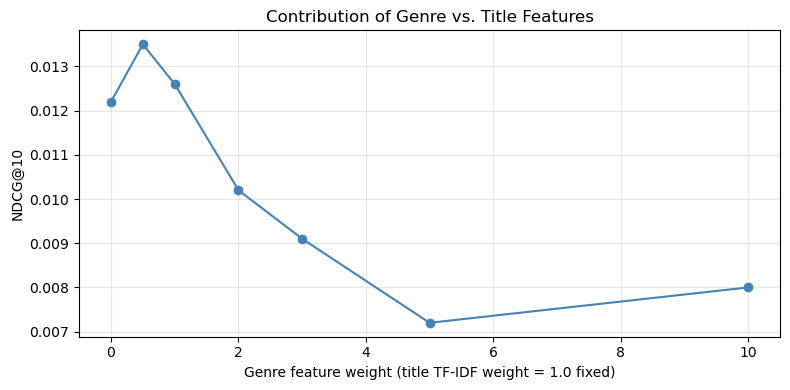

In [13]:
# Test different genre weights to understand their contribution
print(f"{'Genre Weight':>14}  {'HitRate@10':>12}  {'NDCG@10':>10}")

genre_weight_results = []
for gw in [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]:
    feats = l2_normalize(np.hstack([genre_matrix * gw, TFIDF]))

    def score_fn(u, f=feats):
        profile = R[u] @ f
        norm = np.linalg.norm(profile)
        if norm < 1e-10:
            return item_popularity
        return f @ (profile / norm)

    r = evaluate(score_fn, R, test, K=10)
    genre_weight_results.append({"genre_weight": gw, **r})
    print(f"{gw:>14.1f}  {r['HitRate@10']:>12.4f}  {r['NDCG@10']:>10.4f}")

gwr_df = pd.DataFrame(genre_weight_results)
plt.figure(figsize=(8, 4))
plt.plot(gwr_df["genre_weight"], gwr_df["NDCG@10"], marker="o", color="steelblue")
plt.xlabel("Genre feature weight (title TF-IDF weight = 1.0 fixed)")
plt.ylabel("NDCG@10")
plt.title("Contribution of Genre vs. Title Features")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| | Content-Based | Collaborative Filtering |
|---|---|---|
| **Data needed** | Item metadata | User-item interactions |
| **New item cold start** | ✓ Works immediately | ✗ Needs ratings |
| **New user cold start** | ✓ Works with one rating | ✗ Needs history |
| **Explainability** | ✓✓ Feature-level explanations | ✓ Neighbor-level |
| **Serendipity** | ✗ Low — filter bubble | ✓ Higher |
| **Scale** | ✓ O(U × F) per user | ✗ O(U²) or O(I²) |
| **Metadata dependency** | ✗ Only as good as your tags | ✓ None |

**What we learned:**

1. **Item features = L2-normalized vectors** — once normalized, recommendation is a single dot product against the user profile.

2. **Mean-centering the rating weights matters** — otherwise a user's disliked genres contaminate their profile (a 1-star Horror film should push the profile *away* from Horror).

3. **The filter bubble is real and measurable** — diversity of recommendations falls as the user rates more items. Content-based narrows; CF tends to diversify (you get exposed to other users' tastes).

4. **Metadata quality is the ceiling** — with 19 genres and title words, we're limited. In production you'd add: director, cast, plot synopsis embeddings, user-generated tags, visual embeddings from cover art.

5. **Item cold start is solved; user cold start is not** — a new user with 0 ratings still has no profile. The fix: ask for preferences onboarding ("pick 5 genres you like") or fall back to popularity.

**Next**: [03 · Matrix Factorization](../03_matrix_factorization/notebook.ipynb) — learn latent embeddings from the data itself, no hand-crafted features needed, and finally beat the popularity baseline convincingly.